In [6]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical

In [11]:
pip install tensorflow opencv-python numpy matplotlib pillow scikit-learn jupyter

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Using cached jupyter-1.1.1-py2.py3-none-any.whl (2.7 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
Using cached jupyt

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\sachi\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical

# Main dataset path
dataset_path = r"C:\Users\sachi\OneDrive\Desktop\brain_tumor_project\dataset1\DATASET\classification\Training"

# Classes
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Image size for MobileNetV2
IMG_SIZE = 224

# Lists to store data
images = []
labels = []

# Loop through all classes
for label, category in enumerate(classes):

    folder_path = os.path.join(dataset_path, category)

    print(f"Loading {category} images...")

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        # Read image
        img = cv2.imread(img_path)

        # Skip broken images
        if img is None:
            continue

        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize image
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalize image
        img = img / 255.0

        # Store image and label
        images.append(img)
        labels.append(label)

# Convert into numpy arrays
X = np.array(images)
y = np.array(labels)

# One-hot encoding
y = to_categorical(y, num_classes=4)

# Print dataset shapes
print("\nDataset Loaded Successfully!")

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Loading glioma images...
Loading meningioma images...
Loading notumor images...
Loading pituitary images...

Dataset Loaded Successfully!
Images Shape: (5712, 224, 224, 3)
Labels Shape: (5712, 4)


In [17]:
from sklearn.model_selection import train_test_split

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

Training Images: (4569, 224, 224, 3)
Testing Images: (1143, 224, 224, 3)


In [19]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step


In [20]:
base_model.trainable = False

In [25]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [58]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import Input

# Input layer
inputs = Input(shape=(224,224,3))

# Base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=inputs
)

base_model.trainable = False

# Custom layers
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)

outputs = Dense(4, activation='softmax')(x)

# Final model
model = Model(inputs, outputs)

C:\Users\sachi\AppData\Local\Temp\ipykernel_17216\2454055162.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [59]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [60]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 120s 694ms/step - accuracy: 0.5662 - loss: 1.0514 - val_accuracy: 0.8294 - val_loss: 0.5135
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 81s 565ms/step - accuracy: 0.7647 - loss: 0.6097 - val_accuracy: 0.8714 - val_loss: 0.3823
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 542ms/step - accuracy: 0.8192 - loss: 0.4887 - val_accuracy: 0.8731 - val_loss: 0.3428
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 551ms/step - accuracy: 0.8420 - loss: 0.4353 - val_accuracy: 0.8915 - val_loss: 0.3097
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 83s 580ms/step - accuracy: 0.8577 - loss: 0.3955 - val_accuracy: 0.8941 - val_loss: 0.2947
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 83s 580ms/step - accuracy: 0.8652 - loss: 0.3675 - val_accuracy: 0.8871 - val_loss: 0.2947
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 83s 584ms/step - accuracy: 0.8726 - loss: 0.3504 - val_accuracy: 0.8959 - val_loss: 0.2729
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 16915s 119s/step - accuracy: 0.8759 - loss

In [61]:
model.save("brain_tumor_model.keras")

Image Name: enh_Te-glTr_0000.jpg


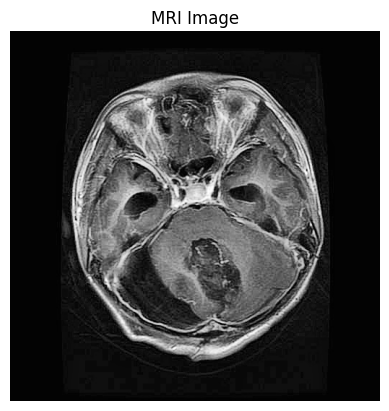

In [62]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Test folder
folder = r"C:\Users\sachi\OneDrive\Desktop\brain_tumor_project\dataset1\DATASET\classification\Testing\glioma"

# First image
img_name = os.listdir(folder)[0]

print("Image Name:", img_name)

# Full path
img_path = os.path.join(folder, img_name)

# Read image
img = cv2.imread(img_path)

# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize
img_resized = cv2.resize(img, (224,224))

# Normalize
img_normalized = img_resized / 255.0

# Expand dimensions
input_image = np.expand_dims(img_normalized, axis=0)

# Display image
plt.imshow(img)

plt.axis("off")

plt.title("MRI Image")

plt.show()

In [63]:
prediction = model.predict(input_image)

predicted_class = np.argmax(prediction)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Predicted Class:", classes[predicted_class])

print("Confidence Scores:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: glioma
Confidence Scores: [[9.9609011e-01 3.7105025e-03 1.9640764e-04 2.9140665e-06]]


In [65]:
!pip install tf-keras-vis


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore

In [67]:
gradcam = Gradcam(model, clone=False)

In [68]:
score = CategoricalScore([predicted_class])

In [69]:
cam = gradcam(score, input_image)

heatmap = cam[0]

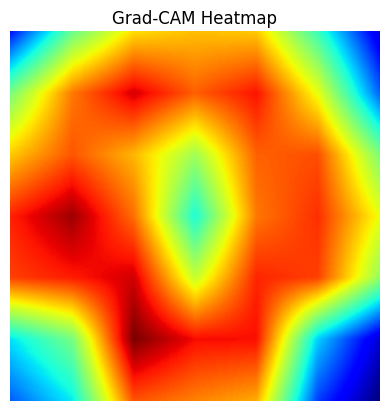

In [70]:
plt.imshow(heatmap, cmap='jet')

plt.title("Grad-CAM Heatmap")

plt.axis("off")

plt.show()

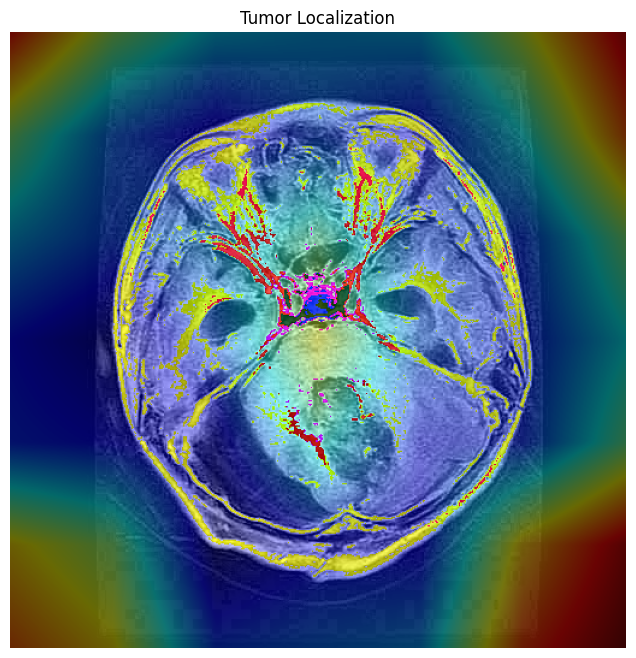

In [71]:
heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

heatmap = np.uint8(255 * heatmap)

heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed_img = heatmap * 0.4 + img

plt.figure(figsize=(8,8))

plt.imshow(superimposed_img.astype("uint8"))

plt.axis("off")

plt.title("Tumor Localization")

plt.show()

In [72]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
